# Module 3 — Appendiceal Cancer: Adverse Reactions

**Prerequisite:** Run `01_appendiceal_explore.ipynb` first to create the `appendiceal_reports` table.

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

db_path = r"C:\Users\palla\OneDrive\Documents\Coding Projects\FDA_FAERS\database\faers.db"
conn = sqlite3.connect(db_path)

### Interpretation

The heatmap above shows adverse reactions with ≥5 reports stratified by drug across the appendiceal cancer population (~339 reports). Given the small cohort size, counts should be interpreted directionally rather than as definitive signal — findings are hypothesis-generating rather than confirmatory.

**Key observations:**

**Fruquintinib — Off label use (n=14, highest signal)**
Fruquintinib received FDA approval in 2023 for refractory metastatic colorectal cancer. Its appearance as the dominant signal in this appendiceal cohort reflects the limited approved treatment options for rare peritoneal malignancies and clinician willingness to use newer agents off-label in heavily pre-treated patients.

**Deep vein thrombosis — cross-drug pattern**
DVT appears across capecitabine, fluorouracil, oxaliplatin, leucovorin, and bevacizumab — the broadest cross-drug signal in this dataset. This reflects cancer-associated thrombosis, a well-documented complication of both the underlying malignancy and chemotherapy in peritoneal disease patients, rather than a drug-specific toxicity.

**Fluorouracil — Stress cardiomyopathy (n=9)**
Consistent with the cardiotoxicity signal identified in Module 1's ROR analysis (cardiotoxicity ROR=15.0). The replication of this signal in the appendiceal indication-filtered population strengthens its clinical relevance.

**Capecitabine — Diarrhoea (n=12) and GI injury (n=10)**
Expected fluoropyrimidine toxicity. Capecitabine is oral 5-FU and shares the same GI toxicity profile documented extensively in Module 1.

**Brain abscess — Capecitabine and Oxaliplatin**
An unusual signal in this cohort. May reflect immunosuppression from chemotherapy or surgical intervention (CRS/HIPEC) creating vulnerability to opportunistic CNS infection. Warrants cautious interpretation given small sample size.

> **Data sparsity caveat:** This cohort contains ~339 reports — among the smallest analyzable populations in this project. All findings should be interpreted as directional signals consistent with known clinical patterns rather than statistically validated conclusions.

In [23]:
##Open appendiceal cohort table created in 01_appendiceal_explore.ipynb and sort by number of reactions reported for each symptom.

appendiceal_cohort_reactions = pd.read_sql_query("""
    SELECT reaction, drugname, COUNT(*) AS reports
    FROM appendiceal_cohort
    GROUP BY drugname, reaction
    HAVING COUNT(*) >= 5
    ORDER BY drugname
    LIMIT 100
    """
    , conn)


appendiceal_cohort_reactions

,reaction,drugname,reports
0,Deep vein thrombosis,BEVACIZUMAB,6
1,Abdominal pain,CAPECITABINE,8
2,Brain abscess,CAPECITABINE,6
3,Deep vein thrombosis,CAPECITABINE,6
4,Diarrhoea,CAPECITABINE,12
5,Fusobacterium infection,CAPECITABINE,6
6,Gastrointestinal injury,CAPECITABINE,10
7,Pneumatosis intestinalis,CAPECITABINE,7
8,Pulmonary embolism,CAPECITABINE,5
9,Pyrexia,CAPECITABINE,8


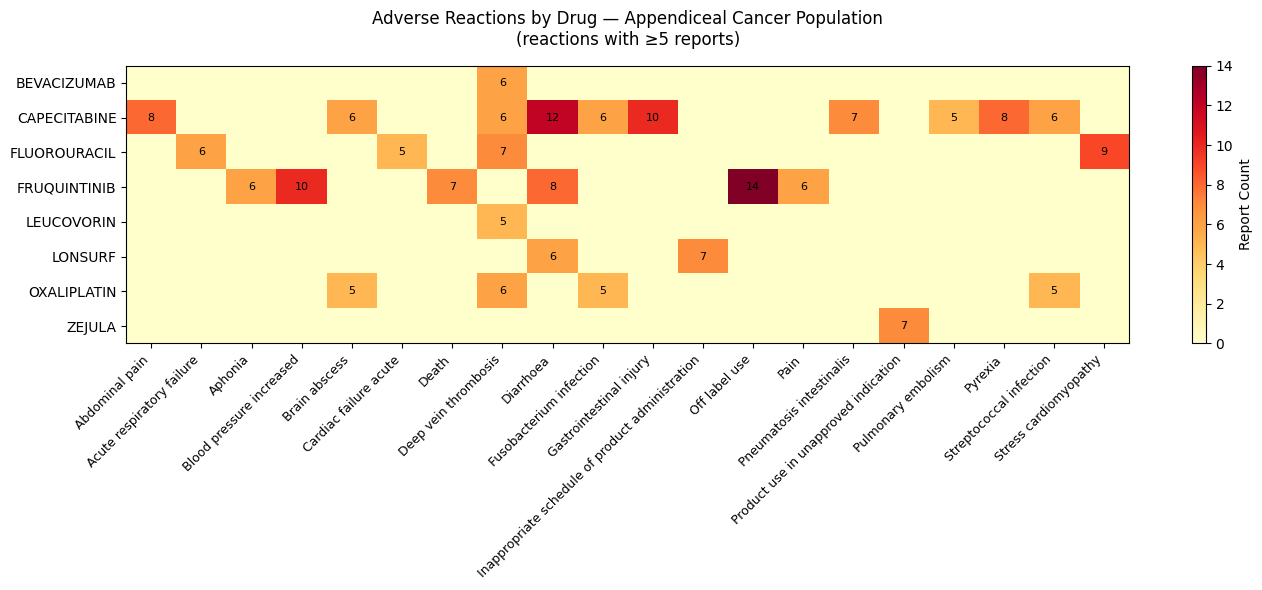

In [25]:
import matplotlib.pyplot as plt
import numpy as np

pivot = appendiceal_cohort_reactions.pivot_table(
    index='drugname',
    columns='reaction',
    values='reports',
    fill_value=0
)



fig, ax = plt.subplots(figsize=(14, 6))

# Create heatmap using imshow
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')

# Set axis labels
ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(pivot.index, fontsize=10)

# Add count annotations inside each cell
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if val > 0:
            ax.text(j, i, str(int(val)), ha='center', va='center',
                    fontsize=8, color='black')

plt.colorbar(im, ax=ax, label='Report Count')
plt.title('Adverse Reactions by Drug — Appendiceal Cancer Population\n(reactions with ≥5 reports)', 
          fontsize=12, pad=15)
plt.tight_layout()
plt.show()


### Interpretation

The heatmap above shows adverse reactions with ≥5 reports stratified by drug across the appendiceal cancer population (~339 reports). Given the small cohort size, counts should be interpreted directionally rather than as definitive signal — findings are hypothesis-generating rather than confirmatory.

**Key observations:**

**Fruquintinib — Off label use (n=14, highest signal)**
Fruquintinib received FDA approval in 2023 for refractory metastatic colorectal cancer. Its appearance as the dominant signal in this appendiceal cohort reflects the limited approved treatment options for rare peritoneal malignancies and clinician willingness to use newer agents off-label in heavily pre-treated patients.

**Deep vein thrombosis — cross-drug pattern**
DVT appears across capecitabine, fluorouracil, oxaliplatin, leucovorin, and bevacizumab — the broadest cross-drug signal in this dataset. This reflects cancer-associated thrombosis, a well-documented complication of both the underlying malignancy and chemotherapy in peritoneal disease patients, rather than a drug-specific toxicity.

**Fluorouracil — Stress cardiomyopathy (n=9)**
Consistent with the cardiotoxicity signal identified in Module 1's ROR analysis (cardiotoxicity ROR=15.0). The replication of this signal in the appendiceal indication-filtered population strengthens its clinical relevance.

**Capecitabine — Diarrhoea (n=12) and GI injury (n=10)**
Expected fluoropyrimidine toxicity. Capecitabine is oral 5-FU and shares the same GI toxicity profile documented extensively in Module 1.

**Brain abscess — Capecitabine and Oxaliplatin**
An unusual signal in this cohort. May reflect immunosuppression from chemotherapy or surgical intervention (CRS/HIPEC) creating vulnerability to opportunistic CNS infection. Warrants cautious interpretation given small sample size.

> **Data sparsity caveat:** This cohort contains ~339 reports — among the smallest analyzable populations in this project. All findings should be interpreted as directional signals consistent with known clinical patterns rather than statistically validated conclusions.
